In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

In [2]:
cal_train = pd.read_csv("data/processed/california_train.csv")
cal_val = pd.read_csv("data/processed/california_val.csv")
display(cal_train.head())
cols = cal_train.columns

rng = np.random.default_rng(0)
bruit_depart_train = 1e-6 * cal_train.std().to_numpy() * rng.uniform(-1, 1, cal_train.shape)   # départage les plafonds
bruit_depart_val = 1e-6 * cal_train.std().to_numpy() * rng.uniform(-1, 1, cal_val.shape)   # départage les plafonds
qt = QuantileTransformer(output_distribution="normal", n_quantiles=1000, subsample=None, random_state=0)

x0_train = torch.from_numpy(qt.fit_transform(cal_train + bruit_depart_train)).float()
x0_val = torch.from_numpy(qt.transform(cal_val + bruit_depart_val)).float()
print(x0_train.shape, x0_val.shape)

train_loader = DataLoader(TensorDataset(x0_train), batch_size=256, shuffle=True)   # même batch que le DDPM

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,1.6900,18.0,4.423529,1.145882,994.0,2.338824,34.14,-116.32,0.542
1,3.3889,32.0,4.338731,1.153497,2725.0,1.764896,33.97,-118.37,2.857
2,6.0074,16.0,6.862705,1.114754,2003.0,4.104508,37.58,-122.08,2.365
3,2.5900,45.0,5.471111,1.131111,1587.0,3.526667,37.74,-122.40,2.118
4,2.2639,15.0,3.845528,0.971545,550.0,2.235772,36.82,-119.72,0.525


torch.Size([14447, 9]) torch.Size([3096, 9])


In [3]:
class Encodeur(nn.Module):
    def __init__(self, d, latent_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,256), nn.SiLU(),
            nn.Linear(256,256), nn.SiLU()            
        )
        self.mu = nn.Linear(256, latent_dim)
        self.log_var = nn.Linear(256, latent_dim)

    def forward(self,x):
        z = self.net(x)
        return self.mu(z), self.log_var(z)

class Decodeur(nn.Module):
    def __init__(self, d, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.SiLU(),
            nn.Linear(256,256), nn.SiLU(),
            nn.Linear(256,d)
        )

    def forward(self,z):
        return self.net(z)

class VAE(nn.Module):
    def __init__(self, d, latent_dim):
        super().__init__()
        self.encodeur = Encodeur(d, latent_dim)
        self.decodeur = Decodeur(d, latent_dim)

    def reparametrize(self, mu, log_var):
        # Dans un but d'inférence (pas de géneration qui est l'utilisation de base d'un VAE)
        # on prédit simplement la moyenne sans échantilloner
        if self.training:
            # std = exp(0.5 * log(sigma^2))
            std = torch.exp(0.5 * log_var)
            eps = torch.randn_like(std)
            return mu + eps*std
        else :
            return mu
            
    def forward(self, x):
        mu, log_var = self.encodeur(x)
        z = self.reparametrize(mu, log_var)
        x_pred = self.decodeur(z)
        return x_pred, mu, log_var

def vae_loss(x, x_pred, mu, log_var):
    rec_loss = F.mse_loss(x_pred, x, reduction='none').sum(dim=1).mean()
    kl_loss = -0.5 * torch.sum(1 + log_var - mu**2 - torch.exp(log_var), dim=1).mean()   # somme sur les dimensions latentes, moyenne sur le batch
    return rec_loss +  kl_loss

California VAE

In [16]:
# validation : bruit du latent fixé une fois pour toutes, comme pour le DDPM
latent_dim = 6
g = torch.Generator().manual_seed(123)
eps_val = torch.randn(len(x0_val), latent_dim, generator=g)

def val_loss_vae(model, x, eps):
    mu, log_var = model.encodeur(x)
    z = mu + torch.exp(0.5 * log_var) * eps
    return vae_loss(x, model.decodeur(z), mu, log_var).item()

os.makedirs("checkpoints", exist_ok=True)

In [17]:
torch.manual_seed(0)

vae = VAE(9, latent_dim=latent_dim)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)   # comme le DDPM
print("paramètres :", sum(p.numel() for p in vae.parameters()))

n_epochs = 200
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    vae.train()
    running_train = 0.0
    for (xb,) in train_loader:
        optimizer.zero_grad()
        out, mu, log_var = vae(xb)
        loss = vae_loss(xb, out, mu, log_var)
        loss.backward()
        optimizer.step()
        running_train += loss.item() * xb.size(0)

    epoch_train_loss = running_train / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Val
    vae.eval()
    with torch.no_grad():
        epoch_val_loss = val_loss_vae(vae, x0_val, eps_val)
    val_losses.append(epoch_val_loss)

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        torch.save(vae.state_dict(), f"checkpoints/vae_california_ep{epoch}.pt")
        print(f"Epoch {epoch:3d}  Train Loss: {epoch_train_loss:.4f}  Val Loss: {epoch_val_loss:.4f}")

paramètres : 141333
Epoch   0  Train Loss: 7.4194  Val Loss: 6.5464
Epoch  20  Train Loss: 6.3431  Val Loss: 6.3470
Epoch  40  Train Loss: 6.3035  Val Loss: 6.3280
Epoch  60  Train Loss: 6.2892  Val Loss: 6.3304
Epoch  80  Train Loss: 6.2673  Val Loss: 6.3158
Epoch 100  Train Loss: 6.2703  Val Loss: 6.3095
Epoch 120  Train Loss: 6.2514  Val Loss: 6.3045
Epoch 140  Train Loss: 6.2672  Val Loss: 6.3060
Epoch 160  Train Loss: 6.2872  Val Loss: 6.2915
Epoch 180  Train Loss: 6.2509  Val Loss: 6.2911
Epoch 199  Train Loss: 6.2462  Val Loss: 6.2821


### Génération
On tire z ~ N(0, I), le décodeur donne x dans l'espace des quantiles, puis on revient aux vraies unités avec `qt.inverse_transform`.

In [18]:
torch.manual_seed(0)
vae.eval()
with torch.no_grad():
    z = torch.randn(len(cal_train), latent_dim)
    x_gen = vae.decodeur(z)

synth = pd.DataFrame(qt.inverse_transform(pd.DataFrame(x_gen.numpy(), columns=cols)), columns=cols)
synth["HouseAge"] = synth["HouseAge"].round()

os.makedirs("data/synthetic", exist_ok=True)
synth.to_csv("data/synthetic/california_vae.csv", index=False)

### Vérifications
Mêmes chiffres que pour le DDPM, avec le DDPM t/T à côté pour comparer.

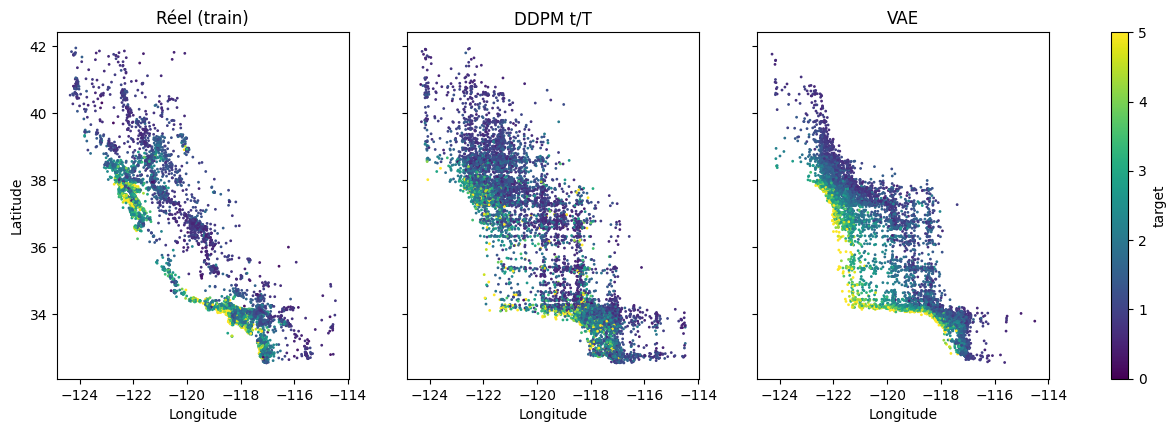

In [19]:
synth_ddpm = pd.read_csv("data/synthetic/california_ddpm_naif.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True, sharey=True)
for ax, (nom, df) in zip(axes, [("Réel (train)", cal_train), ("DDPM t/T", synth_ddpm), ("VAE", synth)]):
    sc = ax.scatter(df["Longitude"], df["Latitude"], c=df["target"], s=1, cmap="viridis", vmin=0, vmax=5)
    ax.set_title(nom)
    ax.set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.colorbar(sc, ax=axes, label="target")
fig.savefig("figures/vae_carte_reel_vs_synth.png", dpi=150, bbox_inches="tight")

In [20]:
from scipy.stats import wasserstein_distance
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

nn_geo = NearestNeighbors(n_neighbors=1).fit(cal_train[["Longitude", "Latitude"]])

for nom, df in [("val réel", cal_val), ("DDPM t/T", synth_ddpm), ("VAE", synth)]:
    w = np.mean([wasserstein_distance(cal_train[c], df[c]) / cal_train[c].std() for c in cols])
    ecart_corr = (cal_train.corr("spearman") - df.corr("spearman")).abs().max().max()
    hors_carte = (nn_geo.kneighbors(df[["Longitude", "Latitude"]])[0][:, 0] > 0.2).mean()
    print(f"{nom:9s} Wasserstein {w:.3f}   écart corr max {ecart_corr:.3f}   hors carte {hors_carte:.3f}   moyenne target {df['target'].mean():.2f}")

for nom, df in [("DDPM t/T", synth_ddpm), ("VAE", synth)]:
    gbm = HistGradientBoostingRegressor(random_state=0, early_stopping=False).fit(df.drop(columns="target"), df["target"])
    r2 = r2_score(cal_val["target"], gbm.predict(cal_val.drop(columns="target")))
    print(f"{nom:9s} R² sur la val d'un GBM entraîné sur le synthétique : {r2:.3f}   (entraîné sur le train réel : 0.833)")

val réel  Wasserstein 0.024   écart corr max 0.038   hors carte 0.005   moyenne target 2.06
DDPM t/T  Wasserstein 0.081   écart corr max 0.094   hors carte 0.040   moyenne target 1.86
VAE       Wasserstein 0.131   écart corr max 0.275   hors carte 0.028   moyenne target 2.00
DDPM t/T  R² sur la val d'un GBM entraîné sur le synthétique : 0.750   (entraîné sur le train réel : 0.833)
VAE       R² sur la val d'un GBM entraîné sur le synthétique : 0.653   (entraîné sur le train réel : 0.833)


In [21]:
# dimensions latentes actives : si la variance de mu sur la val est quasi nulle, la dimension ne sert à rien
with torch.no_grad():
    mu_val, _ = vae.encodeur(x0_val)
var_mu = mu_val.var(dim=0)
print("variance de mu par dimension :", var_mu.numpy().round(3))
print("dimensions actives :", (var_mu > 0.01).sum().item(), "sur", latent_dim)

variance de mu par dimension : [0.804 0.757 0.666 0.615 0.041 0.382]
dimensions actives : 6 sur 6


## MAGIC : VAE conditionné sur la classe

La classe (0 = gamma, 1 = hadron) est ajoutée à l'entrée de l'encodeur et du décodeur. Mêmes réglages que pour California.

In [10]:
magic_train = pd.read_csv("data/processed/magic_train.csv")
magic_val = pd.read_csv("data/processed/magic_val.csv")
cols_m = magic_train.columns.drop("target")

# même préparation que pour le DDPM : quantiles sur les 10 variables, la classe reste en 0/1
rng = np.random.default_rng(0)
bruit_m = 1e-6 * magic_train[cols_m].std().to_numpy() * rng.uniform(-1, 1, magic_train[cols_m].shape)
qt_m = QuantileTransformer(output_distribution="normal", n_quantiles=1000, subsample=None, random_state=0)
x0_m = torch.from_numpy(qt_m.fit_transform(magic_train[cols_m] + bruit_m)).float()
y_m = torch.tensor(magic_train["target"].values).float()

x0_val_m = torch.from_numpy(qt_m.transform(magic_val[cols_m])).float()
y_val_m = torch.tensor(magic_val["target"].values).float()

loader_m = DataLoader(TensorDataset(x0_m, y_m), batch_size=256, shuffle=True)
print(x0_m.shape, "part de hadrons :", y_m.mean().item())

torch.Size([13233, 10]) part de hadrons : 0.3476913869380951


In [11]:
class VAECond(nn.Module):
    def __init__(self, d, latent_dim):
        super().__init__()
        self.encodeur = Encodeur(d + 1, latent_dim)   # x + classe
        self.decodeur = Decodeur(d, latent_dim + 1)   # z + classe

    def forward(self, x, y):
        y = y.unsqueeze(1)
        mu, log_var = self.encodeur(torch.cat([x, y], dim=1))
        z = mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)
        x_pred = self.decodeur(torch.cat([z, y], dim=1))
        return x_pred, mu, log_var


g = torch.Generator().manual_seed(123)
eps_val_m = torch.randn(len(x0_val_m), latent_dim, generator=g)

def val_loss_vae_cond(model, x, y, eps):
    y = y.unsqueeze(1)
    mu, log_var = model.encodeur(torch.cat([x, y], dim=1))
    z = mu + torch.exp(0.5 * log_var) * eps
    return vae_loss(x, model.decodeur(torch.cat([z, y], dim=1)), mu, log_var).item()

In [12]:
torch.manual_seed(0)

d_m = x0_m.shape[1]
vae_m = VAECond(d_m, latent_dim)
optimizer_m = torch.optim.Adam(vae_m.parameters(), lr=1e-3)
print("paramètres :", sum(p.numel() for p in vae_m.parameters()))

for epoch in range(n_epochs):
    vae_m.train()
    total = 0.0
    for xb, yb in loader_m:
        optimizer_m.zero_grad()
        out, mu, log_var = vae_m(xb, yb)
        loss = vae_loss(xb, out, mu, log_var)
        loss.backward()
        optimizer_m.step()
        total += loss.item() * xb.size(0)

    if epoch % 20 == 0 or epoch == n_epochs - 1:
        vae_m.eval()
        with torch.no_grad():
            val_loss = val_loss_vae_cond(vae_m, x0_val_m, y_val_m, eps_val_m)
        torch.save(vae_m.state_dict(), f"checkpoints/vae_magic_ep{epoch}.pt")
        print(f"Epoch {epoch:3d}  Train Loss: {total / len(loader_m.dataset):.4f}  Val Loss: {val_loss:.4f}")

paramètres : 143898
Epoch   0  Train Loss: 7.5719  Val Loss: 6.2742
Epoch  20  Train Loss: 5.3717  Val Loss: 5.4873
Epoch  40  Train Loss: 5.3118  Val Loss: 5.4013
Epoch  60  Train Loss: 5.2967  Val Loss: 5.3662
Epoch  80  Train Loss: 5.2450  Val Loss: 5.3619
Epoch 100  Train Loss: 5.2280  Val Loss: 5.3384
Epoch 120  Train Loss: 5.2405  Val Loss: 5.3336
Epoch 140  Train Loss: 5.2526  Val Loss: 5.3241
Epoch 160  Train Loss: 5.2253  Val Loss: 5.3297
Epoch 180  Train Loss: 5.2330  Val Loss: 5.3309
Epoch 199  Train Loss: 5.2168  Val Loss: 5.3165


In [13]:
torch.manual_seed(0)
n_m = len(magic_train)
y_gen = y_m[torch.randint(0, n_m, (n_m,))]   # classes tirées au hasard dans celles du train

vae_m.eval()
with torch.no_grad():
    z = torch.randn(n_m, latent_dim)
    x_gen_m = vae_m.decodeur(torch.cat([z, y_gen.unsqueeze(1)], dim=1))

synth_m = pd.DataFrame(qt_m.inverse_transform(pd.DataFrame(x_gen_m.numpy(), columns=cols_m)), columns=cols_m)
synth_m["target"] = y_gen.int().numpy()

print("part de hadrons : réel", round(magic_train["target"].mean(), 3), "| synthétique", round(synth_m["target"].mean(), 3))
synth_m.to_csv("data/synthetic/magic_vae.csv", index=False)

part de hadrons : réel 0.348 | synthétique 0.343


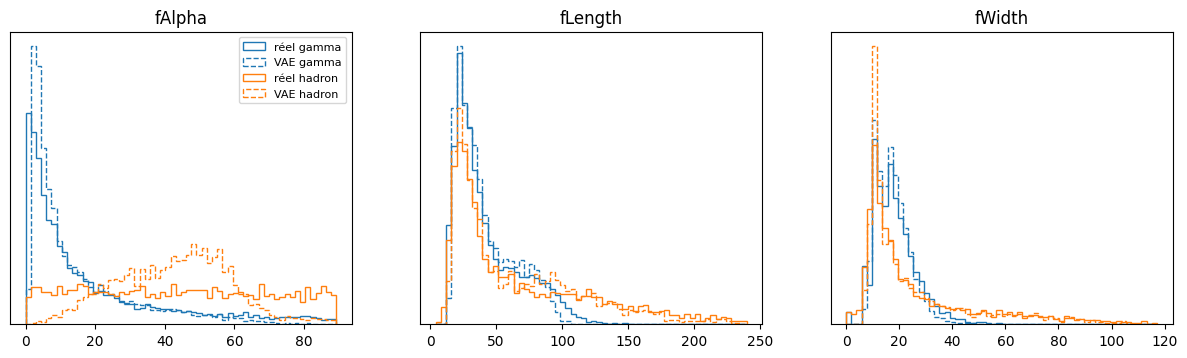

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, c in zip(axes, ["fAlpha", "fLength", "fWidth"]):
    bornes = (magic_train[c].min(), magic_train[c].quantile(0.995))
    for cl, nom, couleur in [(0, "gamma", "C0"), (1, "hadron", "C1")]:
        ax.hist(magic_train.loc[magic_train["target"] == cl, c], bins=60, range=bornes, density=True,
                histtype="step", color=couleur, label=f"réel {nom}")
        ax.hist(synth_m.loc[synth_m["target"] == cl, c], bins=60, range=bornes, density=True,
                histtype="step", color=couleur, linestyle="--", label=f"VAE {nom}")
    ax.set_title(c)
    ax.set_yticks([])
axes[0].legend(fontsize=8)
fig.savefig("figures/vae_magic_reel_vs_synth.png", dpi=150, bbox_inches="tight")

In [15]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

synth_m_ddpm = pd.read_csv("data/synthetic/magic_ddpm.csv")

for nom, df in [("val réel", magic_val), ("DDPM", synth_m_ddpm), ("VAE", synth_m)]:
    w = np.mean([wasserstein_distance(magic_train[c], df[c]) / magic_train[c].std() for c in cols_m])
    ecart_corr = (magic_train.corr("spearman") - df.corr("spearman")).abs().max().max()
    print(f"{nom:9s} Wasserstein {w:.3f}   écart corr max {ecart_corr:.3f}")

for nom, df in [("DDPM", synth_m_ddpm), ("VAE", synth_m)]:
    gbm = HistGradientBoostingClassifier(random_state=0, early_stopping=False).fit(df[cols_m], df["target"])
    auc = roc_auc_score(magic_val["target"], gbm.predict_proba(magic_val[cols_m])[:, 1])
    print(f"{nom:9s} AUC sur la val d'un GBM entraîné sur le synthétique : {auc:.3f}   (entraîné sur le train réel : 0.937)")

with torch.no_grad():
    mu_val_m, _ = vae_m.encodeur(torch.cat([x0_val_m, y_val_m.unsqueeze(1)], dim=1))
print("dimensions actives :", (mu_val_m.var(dim=0) > 0.01).sum().item(), "sur", latent_dim)

val réel  Wasserstein 0.028   écart corr max 0.046
DDPM      Wasserstein 0.038   écart corr max 0.072
VAE       Wasserstein 0.150   écart corr max 0.248
DDPM      AUC sur la val d'un GBM entraîné sur le synthétique : 0.927   (entraîné sur le train réel : 0.937)
VAE       AUC sur la val d'un GBM entraîné sur le synthétique : 0.886   (entraîné sur le train réel : 0.937)
dimensions actives : 5 sur 8
